# Chromatin copy number correction

June 11, 2024

## Goal:
Apply copy number correction to chromatin data

**Procedure:**
1. Load replication timing
2. Load chromatin data for all genes (may take a while, start with a smaller set)
3. Normalize by length distribution
4. Copy number correction
5. Store corrected data for deconvolution


In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [100]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()
mnase_analysis_rep1.normalize_and_compute_raw_replication_timing()

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 00:02:15.486


In [110]:
from src.CopyNumberCorrection import get_bin_for_position

genes = corrector1.genes
gene_positions = genes[[]].copy()
gene_chr_counts = genes[[]].copy()
    
for chrom in range(1, 17):

    chr_genes = genes[genes.chr == chrom]
    start_indices = chr_data_10k.loc[chrom].index

    gene_positions['chr'] = chrom

    for orf_name, gene in chr_genes.iterrows():
        bin_idx, bin_start_bp = get_bin_for_position(gene.TSS, start_indices)
        gene_positions.loc[orf_name, 'bin_start'] = bin_start_bp
        values = chr_data_10k.loc[chrom].loc[bin_start_bp].values
        gene_chr_counts.loc[orf_name, np.arange(len(values))] = values

gene_positions.bin_start = gene_positions.bin_start.astype(int)

In [111]:
genes_repl_profile = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv')
genes_repl_profile = genes_repl_profile.set_index('orf_name')
genes_repl_profile = genes_repl_profile.sort_values('replication_time')
genes_repl_profile.head(2)

,replication_time,replication_H_index
orf_name,,
YGR194C,4.3477,105.0
YGR195W,4.3477,105.0


In [112]:
gene_chr_counts = gene_chr_counts.loc[genes_repl_profile.index]

In [125]:
normalized_chr_counts = gene_chr_counts / gene_chr_counts.sum(axis=0).values.reshape((1, -1))

In [268]:
# For each time points (row)
# Compute the proportion of population that has replicated using the replication indices
# from the deconvolution.

# Create a replication profile from an H, mixture of S
# Decide on which deconvolved timepoints replication will occur for the 
# three positions in the genome

# Early, Mid, Late
t = H.shape[0]
n = len(genes_repl_profile)

# Then for each position, we can compute a proportion of the population that has replicated
# from H
copy2_props_mat = np.zeros((n, t))
for i in range(t):
    for gene_idx in range(n):
        replication_idx = int(genes_repl_profile.iloc[gene_idx].replication_H_index)
        proportion_replicated = H[i, replication_idx:-1].sum()
        copy2_props_mat[gene_idx, i] = proportion_replicated

0

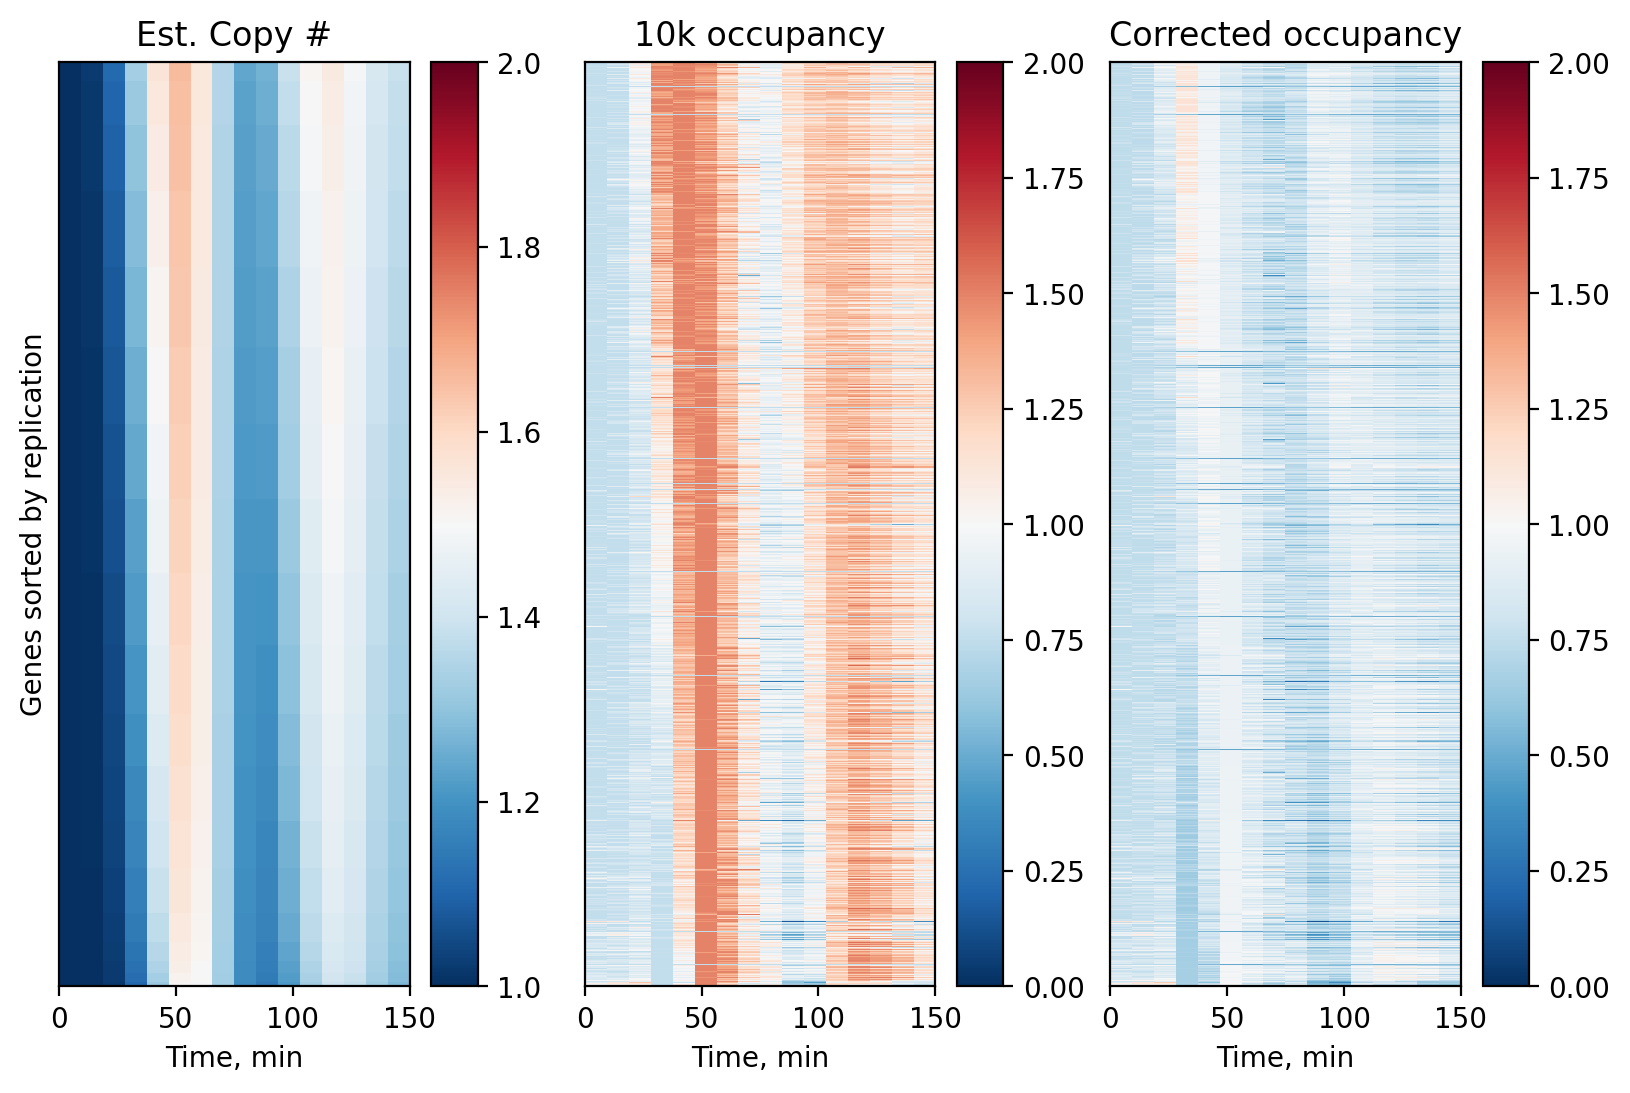

In [391]:
from src.global_config import GlobalConstants

plt.figure(figsize=(13, 6))
plt.subplot(1, 4, 1)
plt.imshow(copy2_props_mat+1, aspect='auto', cmap='RdBu_r', vmin=1, vmax=2.,
           interpolation='none', extent=[0, GlobalConstants.CHROM_WT1_TIMEPOINTS[-1], 
                                         0, len(gene_chr_counts)])
plt.colorbar()
plt.yticks([])
plt.ylabel("Genes sorted by replication")
plt.xlabel("Time, min")
plt.title("Est. Copy #")

plt.subplot(1, 4, 2)
plt.imshow((gene_chr_counts*.75 +0.75), aspect='auto', 
          vmin=0, vmax=2, interpolation='none',
          extent=[0, GlobalConstants.CHROM_WT1_TIMEPOINTS[-1], 0,
                  len(gene_chr_counts)], cmap='RdBu_r')
plt.colorbar()
plt.yticks([])
plt.xlabel("Time, min")
plt.title("10k occupancy")

plt.subplot(1, 4, 3)
corrected_counts = (gene_chr_counts*.75+.75) / ((copy2_props_mat+1.))
normalized_corrected_counts = corrected_counts / \
    corrected_counts.sum(axis=0).values.reshape((1, -1))
plt.imshow(corrected_counts, aspect='auto', 
          vmin=0, vmax=2, interpolation='none',
          extent=[0, GlobalConstants.CHROM_WT1_TIMEPOINTS[-1], 0,
                  len(gene_chr_counts)], cmap='RdBu_r')
plt.colorbar()
plt.yticks([])
plt.xlabel("Time, min")
plt.title("Corrected occupancy")

0

In [400]:
from src.copy_correction_reanalysis import correct_replication_indices

replication_indices = genes_repl_profile.replication_H_index.values.astype(int)

(H_combined_copy_num,
 H_expected_copy_per_gene,
 H_normalized_copy_per_gene) = correct_replication_indices(H, replication_indices)

Text(0.5, 1.0, 'Copy number per gene, normalized\nby overal genome replication timing')

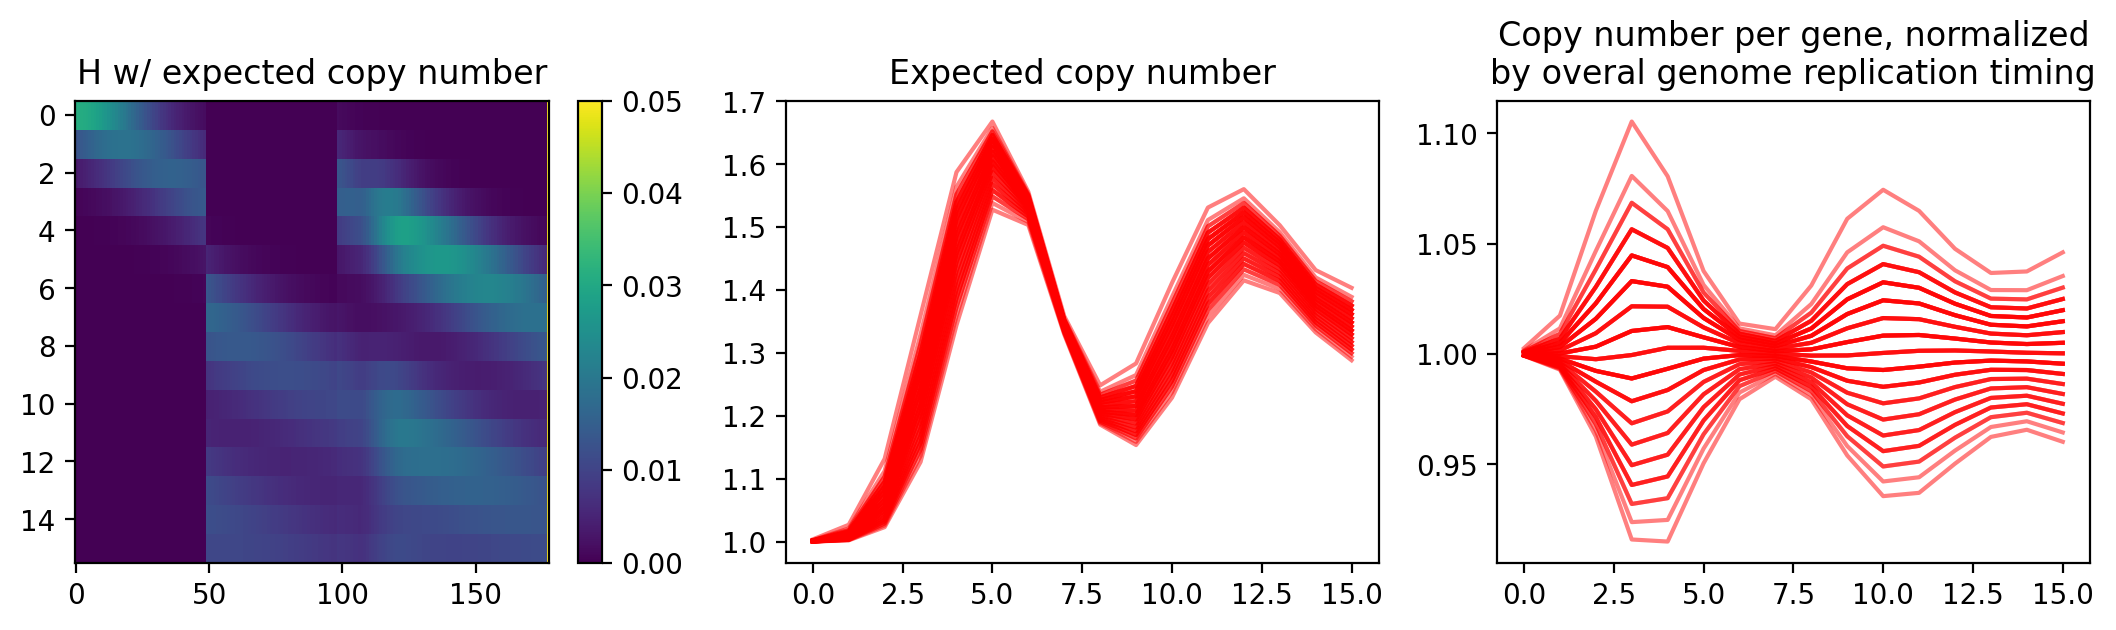

In [418]:
from src.copy_correction_reanalysis import create_copy_number_H, correct_replication_indices

(H_combined_copy_num, 
 H_expected_copy_per_gene, 
 H_normalized_copy_per_gene) = correct_replication_indices(H, replication_indices)

plt.figure(figsize=(13, 3))
plt.subplot(1, 3, 1)
plt.imshow(H_combined_copy_num, vmax=0.05, aspect='auto', interpolation='none')
plt.colorbar()
plt.title("H w/ expected copy number")

n = len(replication_indices)
plt.subplot(1, 3, 2)

H_expected_copy_number_sum = H_expected_copy_per_gene.sum(axis=2)
plt.plot(H_expected_copy_number_sum.T[:, 0:n:100], c='red', alpha=0.5)
plt.title("Expected copy number")

plt.subplot(1, 3, 3)
plt.plot(H_normalized_copy_per_gene[:, 0:n:100], c='red', alpha=0.5)
plt.title("Copy number per gene, normalized\nby overal genome replication timing")


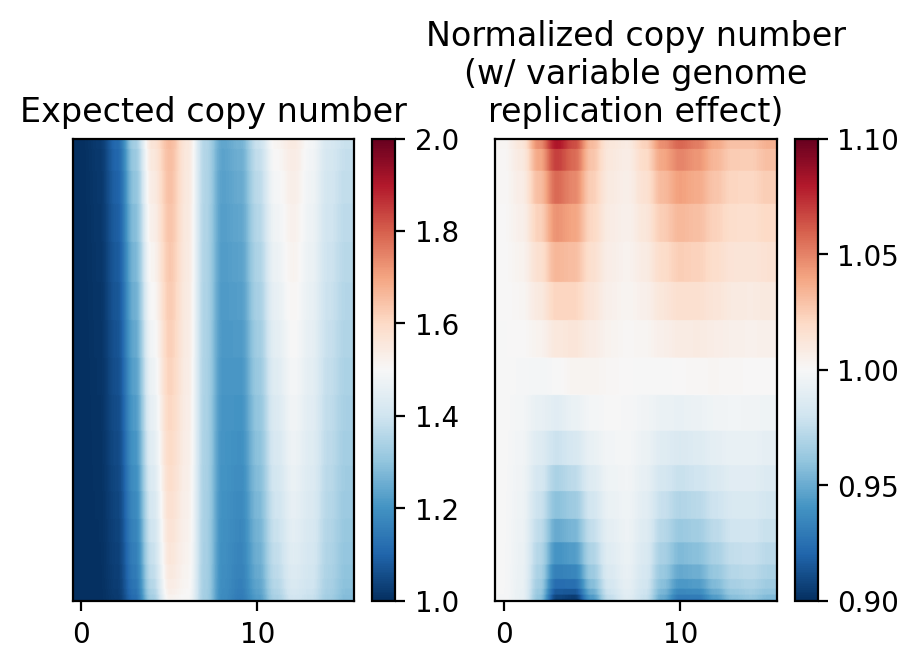

In [426]:
plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1)
plt.imshow(H_expected_copy_number_sum, aspect='auto', cmap='RdBu_r',
           vmin=1, vmax=2.)
plt.yticks([])
plt.title("Expected copy number")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(H_normalized_copy_per_gene.T, aspect='auto', cmap='RdBu_r',
           vmin=0.9, vmax=1.1)
plt.title("Normalized copy number\n(w/ variable genome\nreplication effect)")
plt.yticks([])
plt.colorbar()